# Short-Term Stock Movement Prediction with  ML Models
## David Eister

**Introduction**: The following notebook is used to build and evaluate machine learning models to predict short-term stock price movements using an OHLCV (Open, High, Low, Close, Volume) dataset. Throughout the project, we perform basic exploration, apply standard preprocessing, and compare multiple regression models to understand which approach best captures short-term price behavior

In [1]:
# Loading in all necessary libraries 
from datetime import datetime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
import numpy as np
import warnings
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# I. Exploratory Data Analysis

In [2]:
# Loading our dataset
df=pd.read_csv('stock_details_5_years.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


In [3]:
# Creating our new target variable (% change from open to close in stock pricing)
df["y"] = (df["Close"] - df["Open"]) / df["Open"]
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Company', 'y'],
      dtype='object')

In [4]:
# Using only 2018 and onward data
df['Date'] = pd.to_datetime(df['Date'],utc=True)
df['Date'] = df['Date'].dt.date
df = df[df['Date'] >= datetime(2018, 1, 1).date()]


# Creating rolling average for smoothing based on company
df['Close_MA_7'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df['Open_MA_7'] = df.groupby('Company')['Open'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df['Low_MA_7'] = df.groupby('Company')['Low'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df['High_MA_7'] = df.groupby('Company')['High'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company,y,Close_MA_7,Open_MA_7,Low_MA_7,High_MA_7
0,2018-11-29,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL,-0.017026,43.083508,43.829761,42.639594,43.863354
1,2018-11-29,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT,-0.001269,104.636131,104.769074,103.534595,105.519257
2,2018-11-29,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL,0.010198,54.729000,54.176498,54.099998,55.007500
3,2018-11-29,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN,-0.000848,83.678497,83.749496,82.616501,84.499496
4,2018-11-29,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA,-0.016500,39.037853,39.692784,38.735195,40.064904


In [5]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,y,Close_MA_7,Open_MA_7,Low_MA_7,High_MA_7
count,602962.000000,602962.000000,602962.000000,602962.000000,6.029620e+05,602962.00000,602962.000000,602962.000000,602962.000000,602962.000000,602962.000000,602962.000000
mean,140.074711,141.853492,138.276316,140.095204,5.895601e+06,0.00731,0.000344,0.000247,139.868378,139.848113,138.049680,141.626734
std,275.401725,279.003191,271.895276,275.477969,1.381596e+07,0.12057,0.050607,0.018702,274.861268,274.783844,271.278684,278.397023
min,1.052425,1.061195,1.026114,1.034884,0.000000e+00,0.00000,0.000000,-0.406560,1.073724,1.078735,1.059942,1.095023
25%,39.566159,40.056222,39.058151,39.563746,1.031500e+06,0.00000,0.000000,-0.008605,39.540469,39.544418,39.050728,40.047851
50%,79.177964,80.125563,78.193820,79.177906,2.228700e+06,0.00000,0.000000,0.000261,79.095058,79.091438,78.123259,80.025068
75%,157.837190,159.746317,155.841609,157.847153,5.277400e+06,0.00000,0.000000,0.008929,157.666346,157.641326,155.703180,159.568575
max,6490.259766,6525.000000,6405.000000,6509.350098,1.123003e+09,35.00000,20.000000,0.904175,6374.004255,6385.898577,6318.027134,6447.745745


In this section, we created our target variable as the percentage change from open to close, converted the date column to a proper datetime format, and filtered the dataset to include data from 2018 onward. We also added 7-day rolling averages for each OHLC feature to smooth short-term fluctuations and provide additional trend-based predictors. The summary statistics above give a quick overview of the distributions and scale of the numeric variables used in modeling. Most notably, they show how the OHLC values span a wide range which is indicative of high standard-deviation and variance.

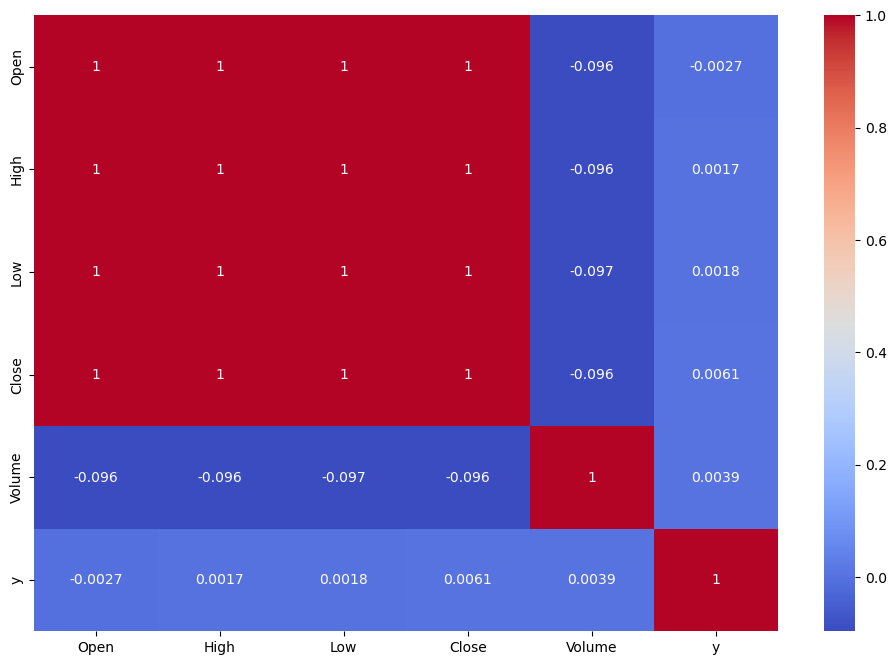

In [6]:
# Plotting heatmap to show numeric correlations for pertinent variables
plt.figure(figsize=(12,8))
sns.heatmap(df[["Open","High","Low","Close","Volume","y"]].corr(), annot=True, cmap="coolwarm")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

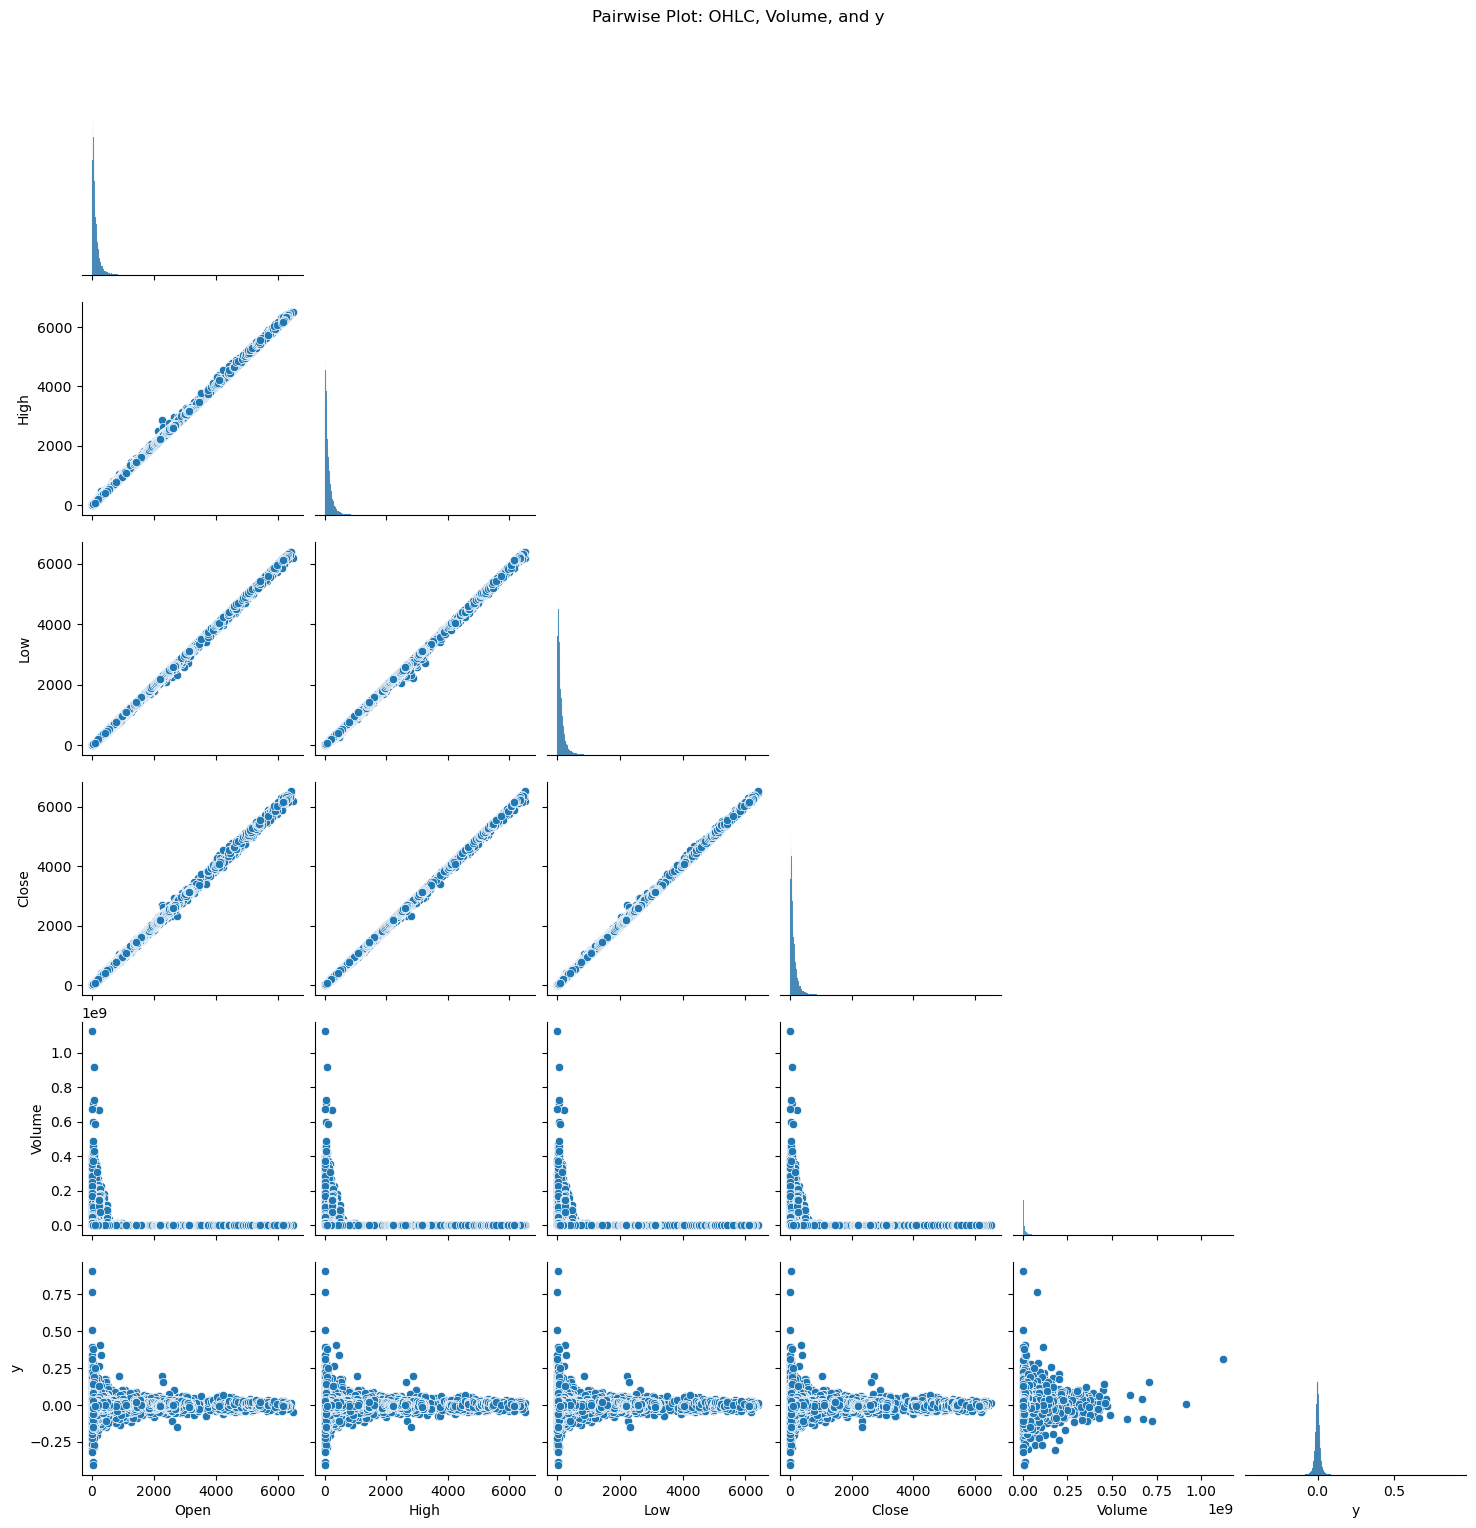

In [7]:
# Pairwise plot for OHLC, Volume, and target column y
sns.pairplot(
    df[["Open", "High", "Low", "Close", "Volume", "y"]],
    diag_kind="hist",
    corner=True
)

plt.suptitle("Pairwise Plot: OHLC, Volume, and y", y=1.02)
plt.show

The correlation heatmap shows that the OHLC features are almost perfectly correlated with one another, which is expected since they come from the same daily pricing structure. Volume exhibits weak relationships with the price-based features, and the target variable y shows only minimal linear correlation, suggesting that nonlinear models may capture the underlying patterns more effectively.

The pairplot further confirms these relationships by illustrating tight linear clustering among the OHLC variables and a wider spread between Volume and y, indicating heteroscedastic behavior and no obvious linear trend. This visualization helps reinforce why linear models may struggle with this dataset.

Finally, the histograms of the numeric variables provide a view of their distributions, showing heavy right-skew in Volume and long-tailed ranges in the OHLC values. These observations help justify later preprocessing choices and inform the selection of models capable of handling variance and nonlinear relationships.

# II. Data Preprocessing

In [8]:
# Drop Date 
df = df.drop(columns=['Date'])

# Separate features and target
X = df.drop(columns=['y'])
y = df['y']

# Get numeric + categorical columns (as lists)
X_num = list(X.select_dtypes(include=['float64', 'int64']).columns)
X_categorical = list(X.select_dtypes(include=['object']).columns)

print("Numeric columns:", X_num)
print("Categorical columns:", X_categorical)

Numeric columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Close_MA_7', 'Open_MA_7', 'Low_MA_7', 'High_MA_7']
Categorical columns: ['Company']


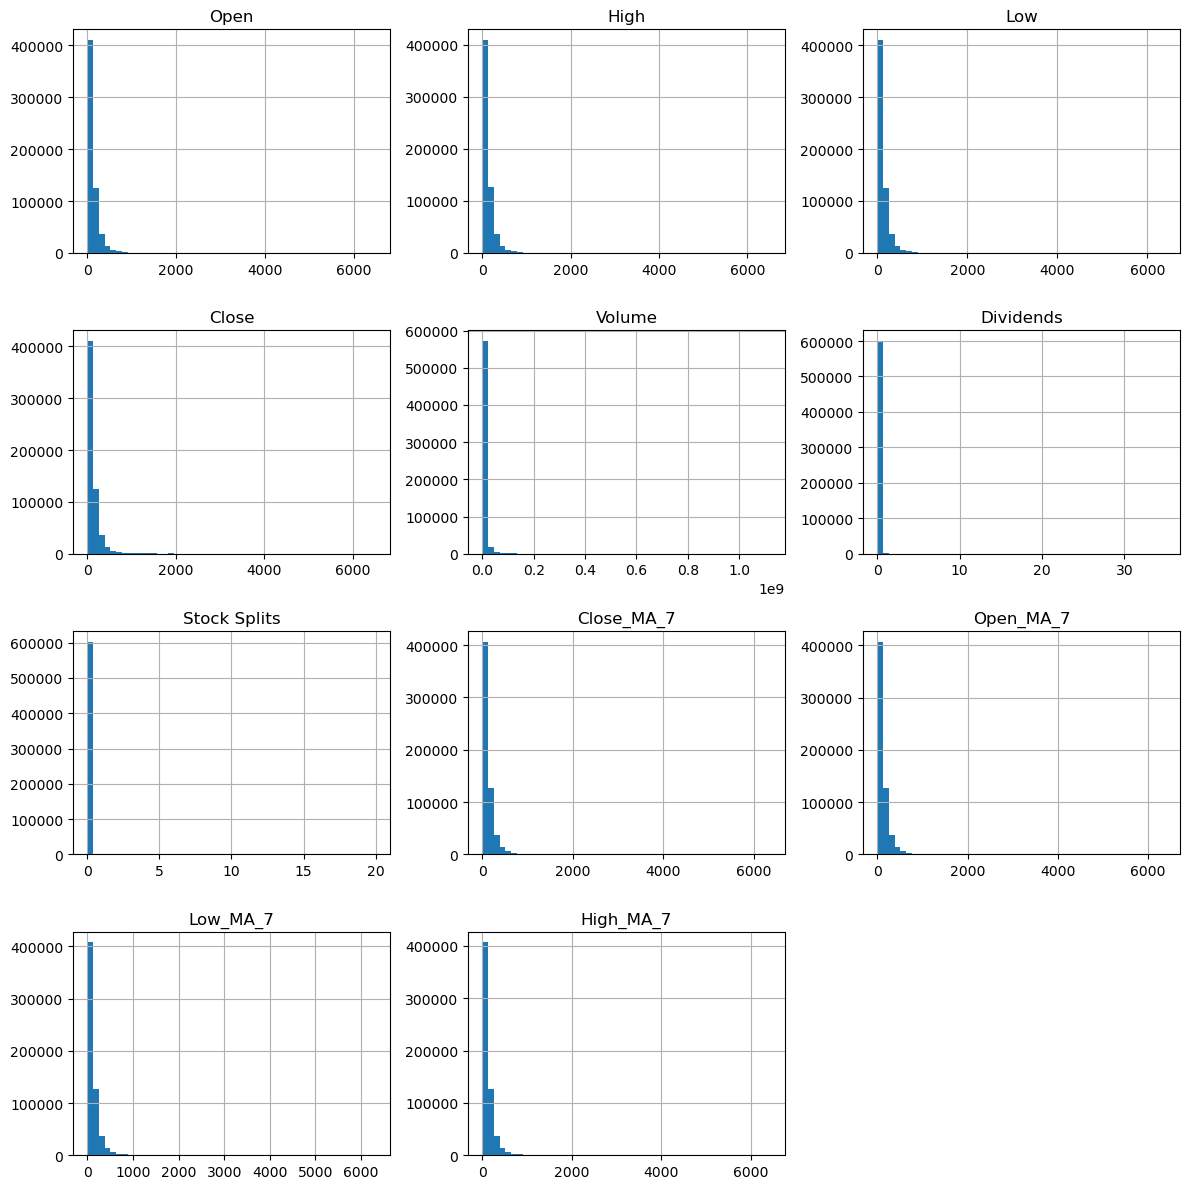

In [9]:
# Plotting histogram of numeric variables
df[X_num].hist(bins=50, figsize=(12,12))
plt.tight_layout()
plt.show()

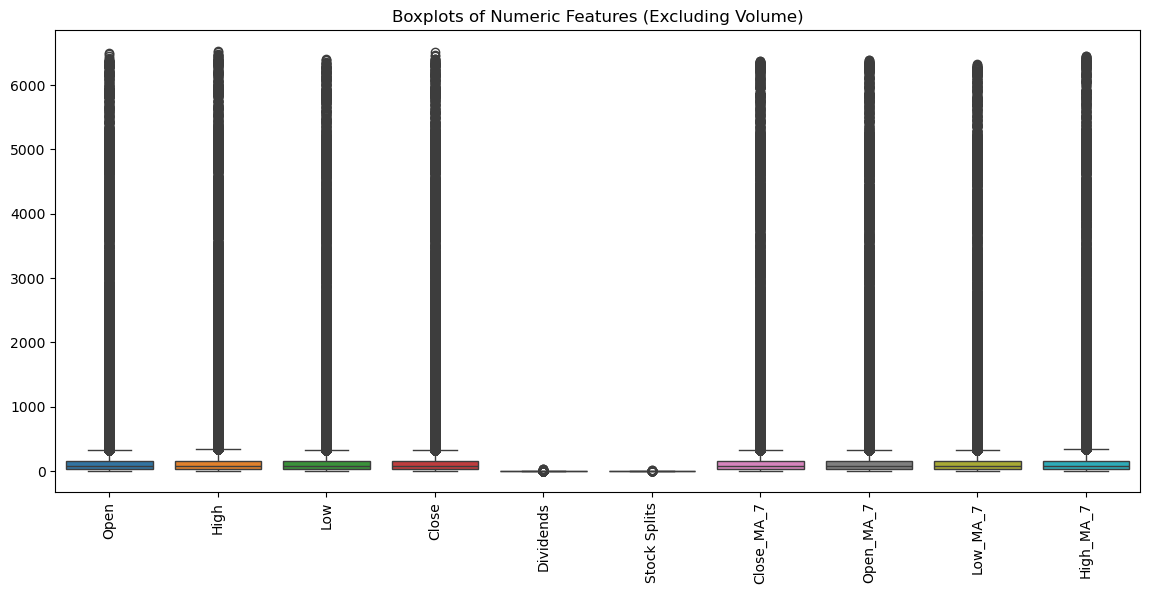

In [10]:
# Removing Volume from the grouped plot to not distort y-axis
cols_no_volume = [col for col in X_num if col != 'Volume']

plt.figure(figsize=(14,6))
sns.boxplot(data=df[cols_no_volume])
plt.xticks(rotation=90)
plt.title("Boxplots of Numeric Features (Excluding Volume)")
plt.show()

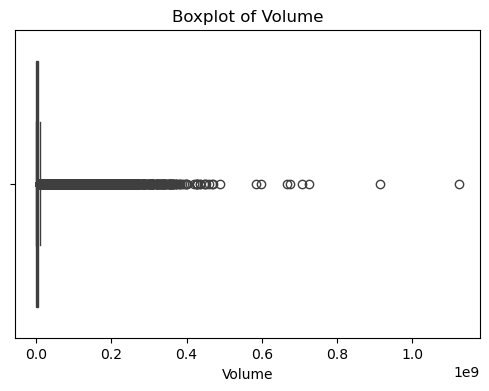

In [11]:
# Standalone Boxplot for Volume
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Volume'])
plt.title("Boxplot of Volume")
plt.show()

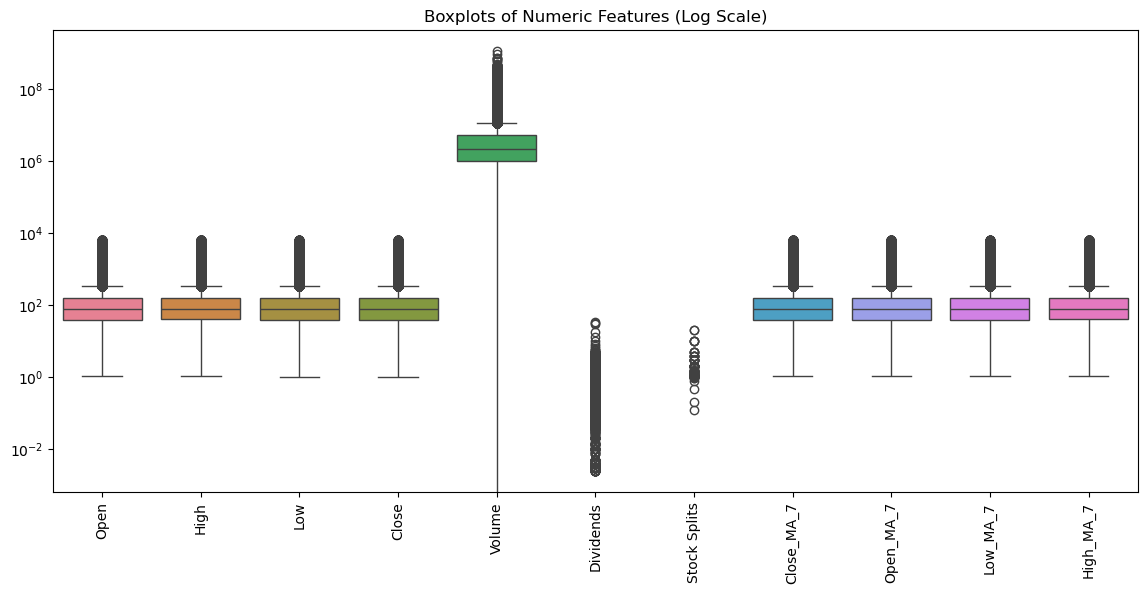

In [12]:
# Log-Scaled Group Plot
plt.figure(figsize=(14,6))
sns.boxplot(data=df[list(X_num)])
plt.yscale('log')
plt.xticks(rotation=90)
plt.title("Boxplots of Numeric Features (Log Scale)")
plt.show()

In [13]:
# Creating preprocess pipeline
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_num),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), X_categorical)
    ]
)

In [14]:
# Fitting on feature matrix
preprocess.fit(X)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Open', 'High', 'Low', 'Close', 'Volume',
                                  'Dividends', 'Stock Splits', 'Close_MA_7',
                                  'Open_MA_7', 'Low_MA_7', 'High_MA_7']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['Company'])])

In [15]:
# Extract scaled numeric features
scaled_num = preprocess.named_transformers_['num'].transform(X[X_num])

In [16]:
# Convert to DataFrame
scaled_num_df = pd.DataFrame(scaled_num, columns=X_num)

scaled_num_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Close_MA_7,Open_MA_7,Low_MA_7,High_MA_7
0,-0.349471,-0.351215,-0.351741,-0.352158,11.666544,-0.060626,-0.006803,-0.352123,-0.349433,-0.351705,-0.351166
1,-0.128197,-0.130229,-0.127776,-0.128718,1.608836,-0.060626,-0.006803,-0.128182,-0.127661,-0.127231,-0.129698
2,-0.311902,-0.311273,-0.309591,-0.309884,1.817349,-0.060626,-0.006803,-0.309754,-0.311778,-0.309459,-0.311136
3,-0.204520,-0.205568,-0.204711,-0.204796,9.146559,-0.060626,-0.006803,-0.204430,-0.204156,-0.204341,-0.205201
4,-0.364493,-0.364830,-0.366101,-0.366844,3.548189,0.271132,-0.006803,-0.366842,-0.364488,-0.366098,-0.364810


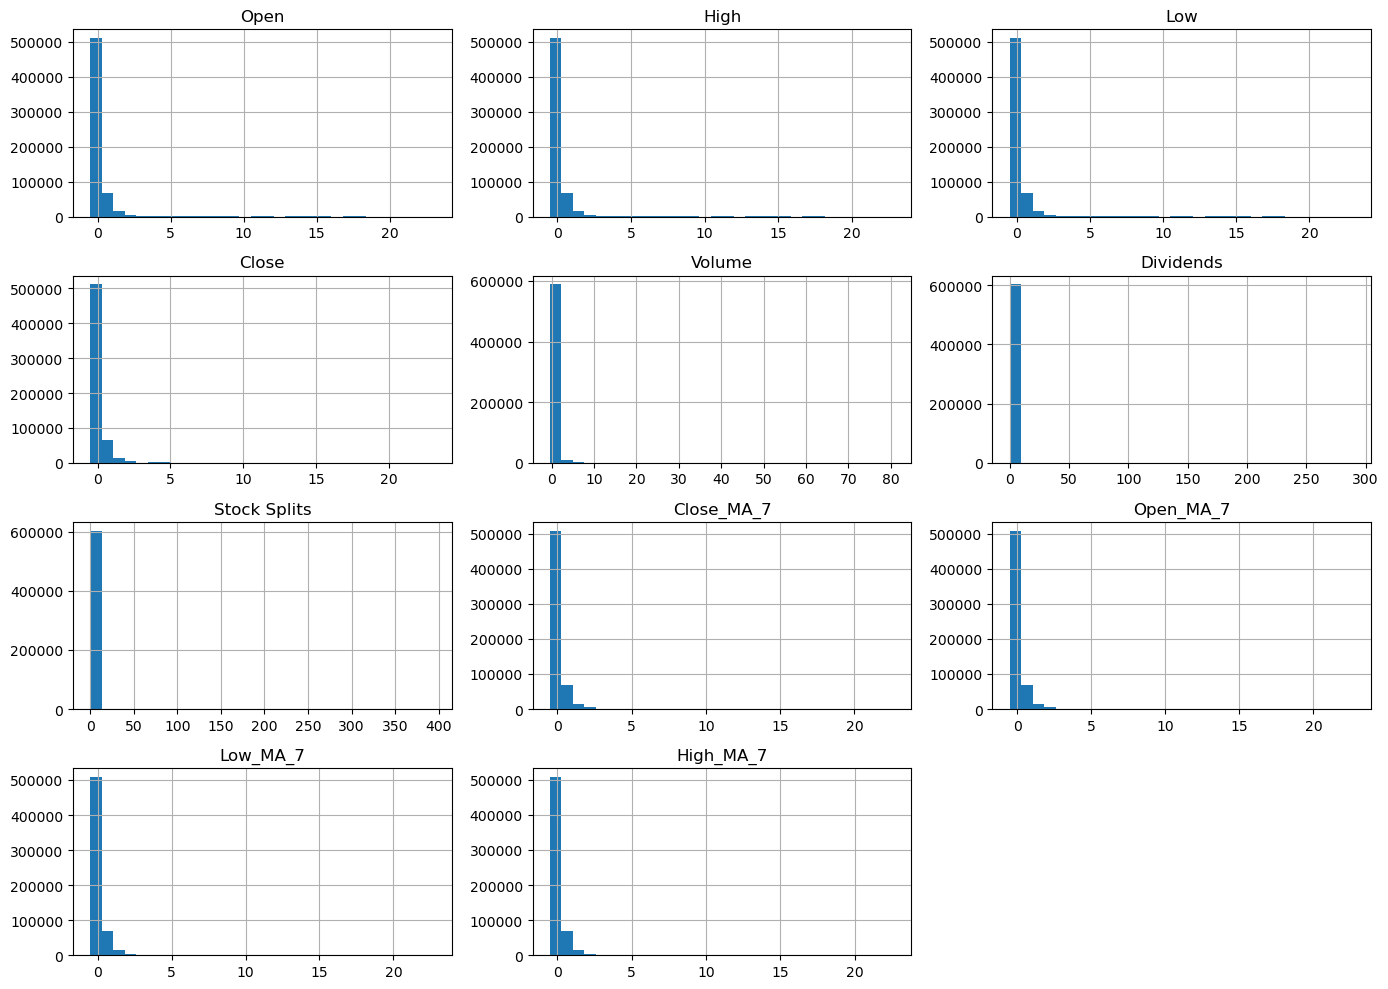

In [17]:
# Plotting histograms of scaled numeric features
scaled_num_df.hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

After separating our features, defining numeric and categorical columns, and standardizing the numerical variables, we visualized the distributions to validate our preprocessing steps. The histograms show how each transformed feature behaves, highlighting the strong right-skew present across the original OHLC, Volume, and rolling-average variables. Boxplots were also generated (both with and without Volume to account for its much larger scale), and a log-scaled version was used to compare all numeric features more effectively. These plots confirm the wide variability and skewed nature of the dataset while ensuring that the standardized values are now suitable for model training. We will now look at the effectiveness of PCA as a dimensionality reduction technique.

Variance Explained per Principal Component:
[7.28040603e-01 9.20498841e-02 9.09925452e-02 8.87171568e-02
 1.61708211e-04 1.62769653e-05 1.59099246e-05 2.36941791e-06
 2.23608880e-06 1.03252153e-06 2.77261425e-07]


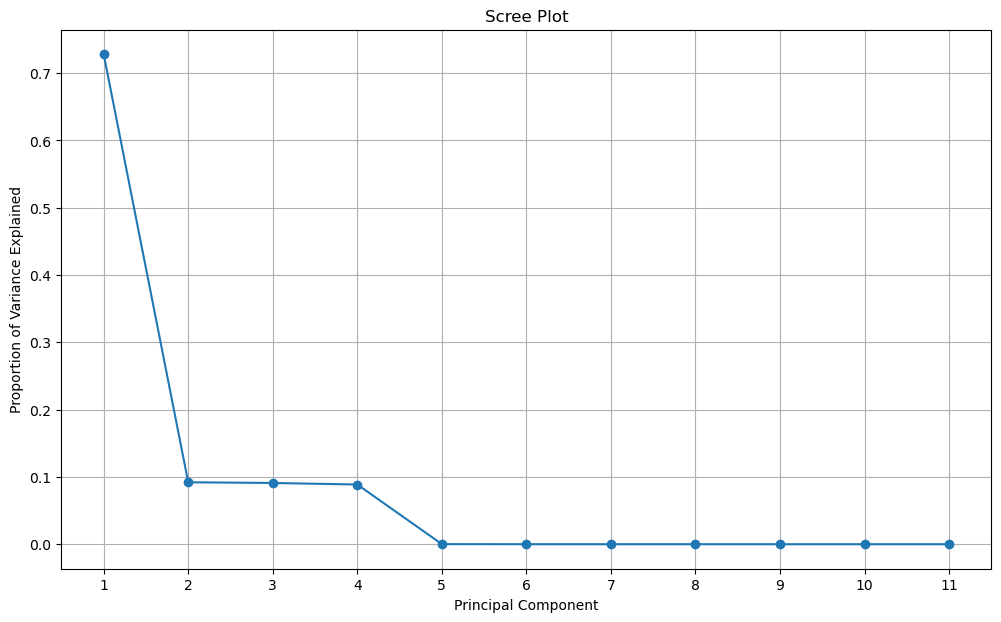

In [18]:
# Using scaled numeric DataFrame
X_pca_input = scaled_num_df.values   # convert to NumPy array

# Number of components = number of columns
n_components = scaled_num_df.shape[1]

# Fit PCA
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_pca_input)

# Variance explained
variance_explained = pca.explained_variance_ratio_
print("Variance Explained per Principal Component:")
print(variance_explained)

# Scree plot
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(variance_explained) + 1),
         variance_explained, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot')
plt.xticks(range(1, len(variance_explained) + 1))
plt.grid(True)
plt.show()

The scree plot shows that the principal components do not capture a strong amount of variance early on. Next, we calculate the cumulative explained variance to determine how many components are required to retain 95% of the total variance

Number of components to explain 95.0% variance: 4


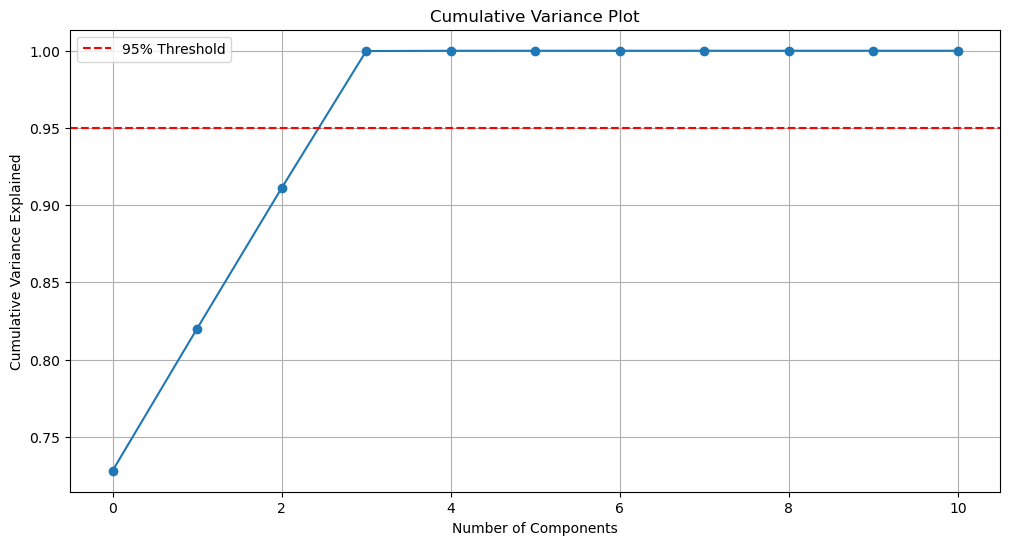

In [19]:
# Plotting cumulative variance with a 95% threshold 
cumulative_variance = np.cumsum(variance_explained)
threshold = 0.95

n_components_for_95 = np.argmax(cumulative_variance >= threshold) + 1
print(f"Number of components to explain {threshold*100}% variance:", 
      n_components_for_95)

plt.figure(figsize=(12,6))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=threshold, color='r', linestyle='--', label='95% Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Plot')
plt.legend()
plt.grid(True)
plt.show()

Our analysis shows that four components are sufficient to capture the target level of variance. We therefore evaluate both PCA-based models (using 4 components) and models without PCA to determine which configuration yields better performance.

In [20]:
optimal_components = 4

# Use the already-fitted PCA object
X_pca_optimal = X_pca[:, :optimal_components]

# Turn into DataFrame
X_pca_optimal_df = pd.DataFrame(
    X_pca_optimal,
    columns=[f'PC{i+1}' for i in range(optimal_components)]
)

X_pca_optimal_df.head()

,PC1,PC2,PC3,PC4
0,-1.444768,7.063888,-0.641632,9.203295
1,-0.425650,0.979740,-0.137284,1.250667
2,-0.948498,1.093267,-0.145128,1.400818
3,-0.933302,5.545924,-0.516600,7.218257
4,-1.169657,2.039948,0.070266,2.863192


Using the optimal four components, we transform the standardized features into a reduced PCA feature set for use in our comparative modeling.

# III. Model Selection and Evaluation

We begin with an unsupervised model to explore the dataset’s underlying structure.

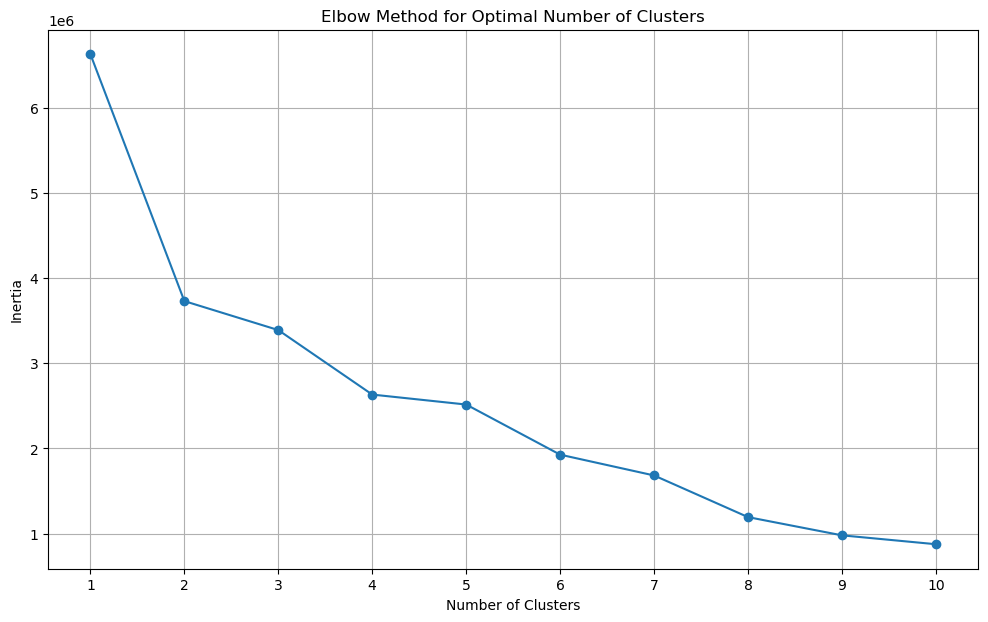

In [21]:
# Use only the PCA-transformed features (PC1–PC4)
X_cluster = X_pca_optimal_df.values

inertia_values = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow method
plt.figure(figsize=(12, 7))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

The optimal number of clusters appears to be four, which is what we will now use.

In [22]:
# Fit KMeans using optimal number of clusters = 4
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca_optimal_df.values)

# Create dataframe with PCA + cluster labels
X_pca_clusters = X_pca_optimal_df.copy()
X_pca_clusters['Cluster'] = labels

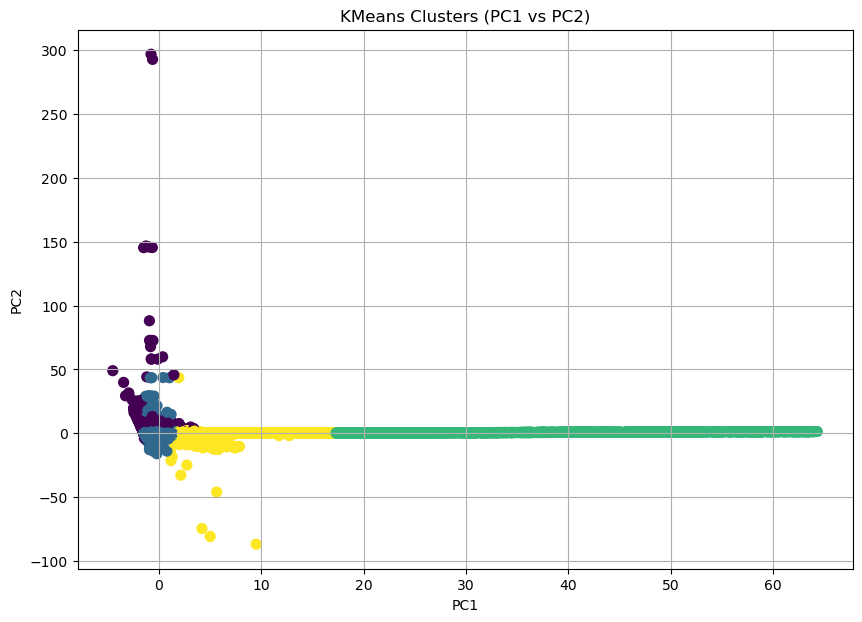

In [23]:
# Plotting KMeans clusters using PC1 vs PC2
plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca_clusters['PC1'],
    X_pca_clusters['PC2'],
    c=X_pca_clusters['Cluster'],
    cmap='viridis',
    s=50
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (PC1 vs PC2)')
plt.grid(True)
plt.show()

The K-Means model with four clusters reveals how the PCA-transformed observations group based on underlying variance patterns rather than labeled outcomes. The scatter plot of PC1 vs. PC2 shows distinct cluster separations for some regions of the feature space, while other areas remain more blended, indicating that the inherent structure of the data is not strongly partitioned. This suggests that unsupervised clustering provides limited predictive insight for our target variable, reinforcing the need for supervised models in the next stage where we will do regression modeling

Linear Regression R²: 0.22230249328684693


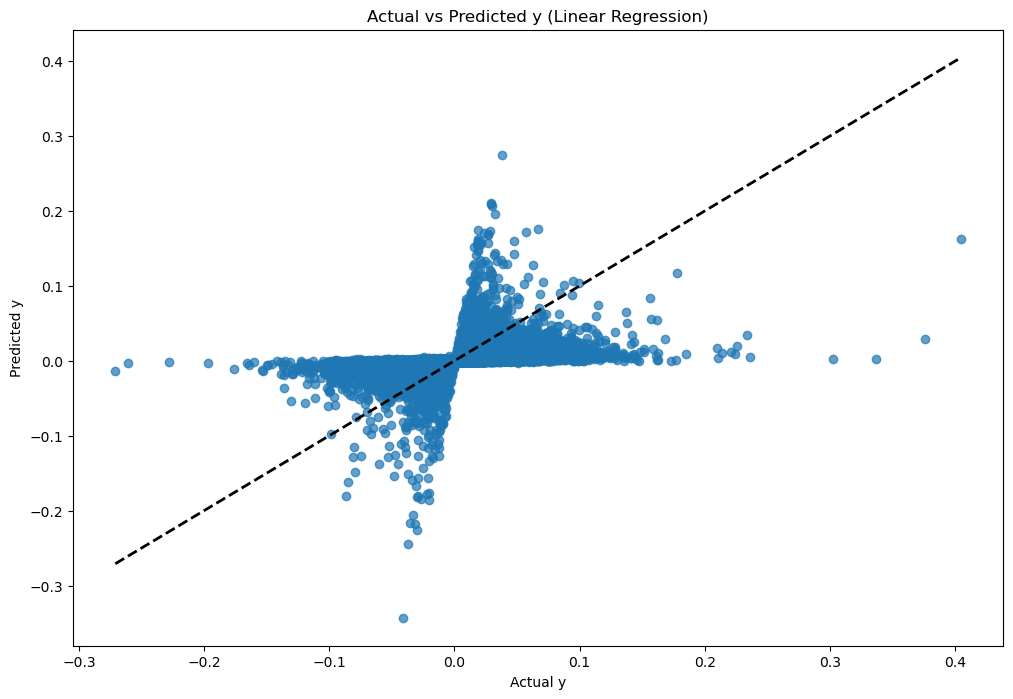

In [24]:
# Separate features and target
X = df.drop(columns=['y'])
y = df['y']

# Build a modeling pipeline with preprocessing + linear regression
model_lr = Pipeline([
    ('preprocess', preprocess),       
    ('lr', LinearRegression())
])

# Train/test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
model_lr.fit(X_train_lr, y_train_lr)

# Predict
y_pred_lr = model_lr.predict(X_test_lr)

# Accuracy Score (R²)
print("Linear Regression R²:", model_lr.score(X_test_lr, y_test_lr))

# Visualization
plt.figure(figsize=(12, 8))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.7)
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Actual vs Predicted y (Linear Regression)')
plt.plot([y_test_lr.min(), y_test_lr.max()],
         [y_test_lr.min(), y_test_lr.max()], 'k--', lw=2)
plt.show()

KNN Regression R² (with PCA): -0.19485940707379412


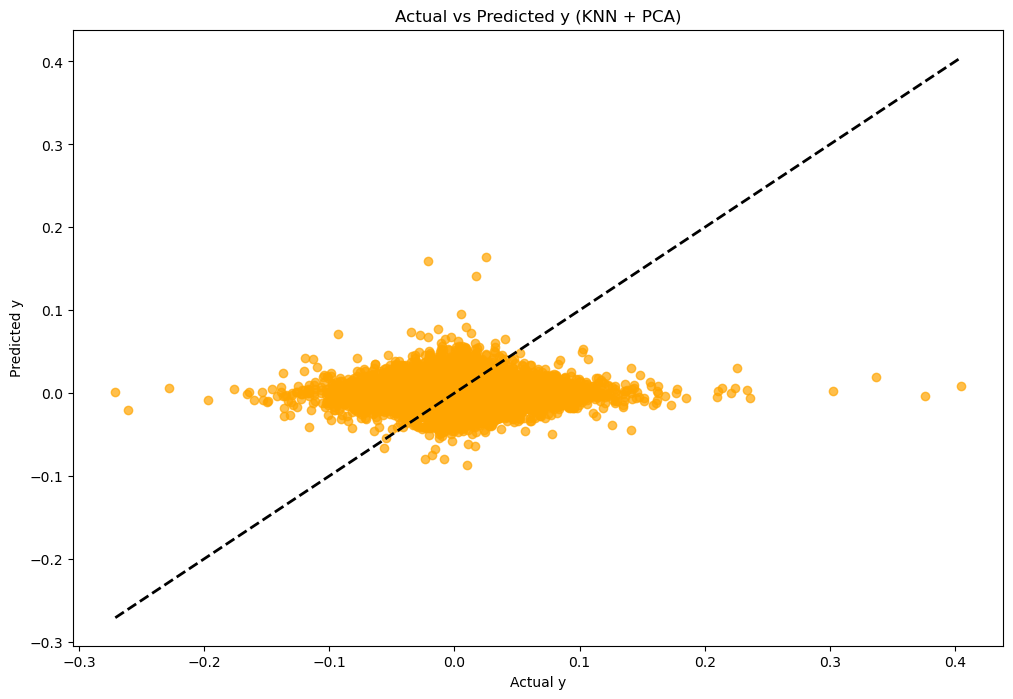

Mean Squared Error (KNN + PCA): 0.0004131123993144989
R² Score (KNN + PCA): -0.19485940707379412
Mean Absolute Error (KNN + PCA): 0.01431528853738005


In [25]:
# Feature & target
X = df.drop(columns=['y'])
y = df['y']

# Build pipeline: preprocess → PCA → KNN
knn_pca_model = Pipeline([
    ('preprocess', preprocess),          # scaling + one-hot encoding
    ('pca', PCA(n_components=4)),        # reduce dimensions 
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

# Train/test split
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
knn_pca_model.fit(X_train_knn, y_train_knn)

# Predict
y_pred_knn = knn_pca_model.predict(X_test_knn)

# R² Score
print("KNN Regression R² (with PCA):", knn_pca_model.score(X_test_knn, y_test_knn))

# Visualization
plt.figure(figsize=(12, 8))
plt.scatter(y_test_knn, y_pred_knn, alpha=0.7, color='orange')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Actual vs Predicted y (KNN + PCA)')
plt.plot(
    [y_test_knn.min(), y_test_knn.max()],
    [y_test_knn.min(), y_test_knn.max()],
    'k--', lw=2
)
plt.show()

# Error metrics
mse_knn = mean_squared_error(y_test_knn, y_pred_knn)
r2_knn  = r2_score(y_test_knn, y_pred_knn)
mae_knn = mean_absolute_error(y_test_knn, y_pred_knn)

print(f"Mean Squared Error (KNN + PCA): {mse_knn}")
print(f"R² Score (KNN + PCA): {r2_knn}")
print(f"Mean Absolute Error (KNN + PCA): {mae_knn}")

In [26]:
# Make a full copy BEFORE modifying df for Decision Tree since we drop 'Company' and 'Date'
df_full = df.copy()

Decision Tree Regression R²: 0.9586183691513109
MSE: 1.4307344199862846e-05
MAE: 0.0012250399986875593


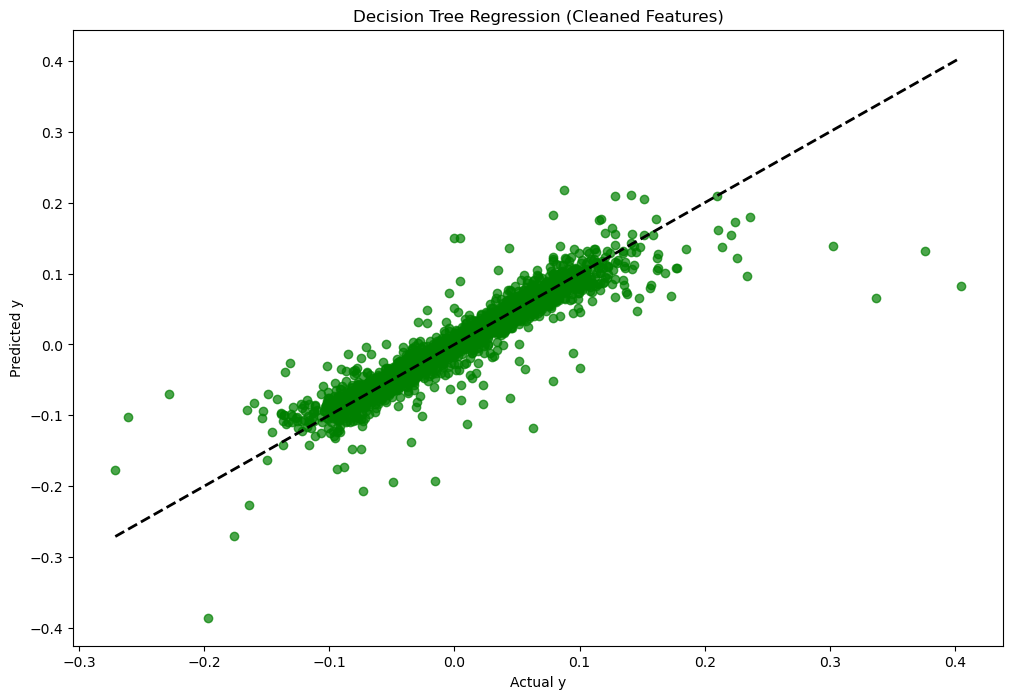

In [27]:
# Drop categorical columns 
df_model = df.drop(columns=['Company', 'Date'], errors='ignore')

# Separate features and target
X = df_model.drop(columns=['y'])
y = df['y']

# Train/test split
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_dt, y_train_dt)

# Predict
y_pred_dt = dt_reg.predict(X_test_dt)

# Metrics
print("Decision Tree Regression R²:", r2_score(y_test_dt, y_pred_dt))
print("MSE:", mean_squared_error(y_test_dt, y_pred_dt))
print("MAE:", mean_absolute_error(y_test_dt, y_pred_dt))

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(y_test_dt, y_pred_dt, alpha=0.7, color='green')
plt.plot([y_test_dt.min(), y_test_dt.max()],
         [y_test_dt.min(), y_test_dt.max()], 'k--', lw=2)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Decision Tree Regression (Cleaned Features)")
plt.show()

Across the three regression models evaluated, Linear Regression performed poorly, showing a weak linear relationship between actual and predicted values and yielding a low R² score. The KNN model with PCA performed even worse, as dimensionality reduction removed important structure and caused the predictions to cluster tightly around zero, resulting in a negative R² score. In contrast, the Decision Tree Regressor demonstrated a strong fit, with predictions closely aligning to the diagonal and achieving a substantially higher R² along with low error metrics. Overall, these results indicate that nonlinear models such as decision trees are better suited for capturing the complex relationships present in our stock-derived features.

# IV. Cross-Validation and Hyperparameter tuning

In [28]:
# Rebuild LR/KNN features from full dataset
X_lr = df_full.drop(columns=['y'])
y_lr = df_full['y']

In [29]:
# -------------------------
# Linear Regression CV (uses original full df)
# -------------------------
scores_lr = cross_val_score(
    model_lr,
    X_lr, y_lr,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
lr_rmse = -scores_lr.mean()

# -------------------------
# KNN (with PCA) CV (also uses full df)
# -------------------------
scores_knn = cross_val_score(
    knn_pca_model,
    X_lr, y_lr,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
knn_rmse = -scores_knn.mean()

# -------------------------
# Decision Tree CV (uses cleaned df)
# -------------------------
X_dt = df_model.drop(columns=['y'])
y_dt = df_model['y']

scores_dt = cross_val_score(
    dt_reg,
    X_dt, y_dt,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
dt_rmse = -scores_dt.mean()

# -------------------------
# Create comparison table
# -------------------------
cv_results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN (PCA)", "Decision Tree"],
    "Mean CV RMSE": [lr_rmse, knn_rmse, dt_rmse]
}).sort_values(by="Mean CV RMSE")

cv_results

c:\Users\David Eister\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\David Eister\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,Mean CV RMSE
2,Decision Tree,0.004590
0,Linear Regression,0.016381
1,KNN (PCA),0.020238


In [30]:
#Linear Model
lr_rmses = -cross_val_score(model_lr, X_train_lr, y_train_lr, scoring="neg_root_mean_squared_error", cv=5)
pd.Series(lr_rmses).describe()

count    5.000000
mean     0.016810
std      0.000170
min      0.016658
25%      0.016681
50%      0.016727
75%      0.016955
max      0.017029
dtype: float64

In [31]:
#KNN Model
knn_rmses = -cross_val_score(knn_pca_model, X_train_knn, y_train_knn, scoring="neg_root_mean_squared_error", cv=5)
pd.Series(knn_rmses).describe()

count    5.000000
mean     0.020531
std      0.000133
min      0.020379
25%      0.020458
50%      0.020526
75%      0.020554
max      0.020736
dtype: float64

In [32]:
#Decision Tree Model
dt_rmses = -cross_val_score(dt_reg, X_train_dt, y_train_dt, scoring="neg_root_mean_squared_error", cv=5)
pd.Series(dt_rmses).describe()

count    5.000000
mean     0.004476
std      0.000680
min      0.003814
25%      0.004035
50%      0.004177
75%      0.004907
max      0.005446
dtype: float64

In [33]:
# Parameter grid
dt_params = {
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': [None, 'sqrt']
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

dt_grid.fit(X_train_dt, y_train_dt)

print("Best parameters:", dt_grid.best_params_)
print("Best CV RMSE:", -dt_grid.best_score_)

Best parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV RMSE: 0.004476113056176151


In [34]:
# Predict using best estimator
best_dt = dt_grid.best_estimator_
y_pred_best = best_dt.predict(X_test_dt)

# Compute MSE
mse = mean_squared_error(y_test_dt, y_pred_best)

# Compute RMSE manually
rmse = np.sqrt(mse)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R²:", r2_score(y_test_dt, y_pred_best))

Test MSE: 1.4307344199862846e-05
Test RMSE: 0.0037825050165020066
Test R²: 0.9586183691513109


To validate the stability of our baseline models, we performed 5-fold cross-validation on Linear Regression, KNN (with PCA), and the Decision Tree Regressor. The mean RMSE values show a clear performance ranking: the Decision Tree achieved the lowest cross-validated error, while Linear Regression and KNN (with PCA) performed substantially worse, consistent with earlier test-set evaluations. This confirms that the nonlinear structure of the data is better captured by tree-based methods, and that PCA further degrades performance for KNN by removing informative variance patterns.

Given the Decision Tree’s strong and consistent baseline performance, we proceeded with hyperparameter tuning using GridSearchCV. The parameter grid explored variations in tree depth, minimum samples per split, minimum samples per leaf, and the number of features considered at each split. The best model emerged with unrestricted depth, one minimum sample per leaf, and sqrt-based feature selection, yielding the lowest cross-validated RMSE among the tested configurations. Notably, the tuned model produced nearly identical results to the baseline Decision Tree, indicating that the model was already operating near its optimal form. When evaluated on the test set, the optimized tree again achieved a very low RMSE and a high R² score, reaffirming it as the most effective model for capturing the relationships in our dataset.